# Tutorials and Examples

examples

Gaussian Covariance Model

C:\Users\barbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\gstools\field\plot.py:401: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: title={'center': 'Field 2D structured: (100, 100)'}, xlabel='$x$', ylabel='$y$'>

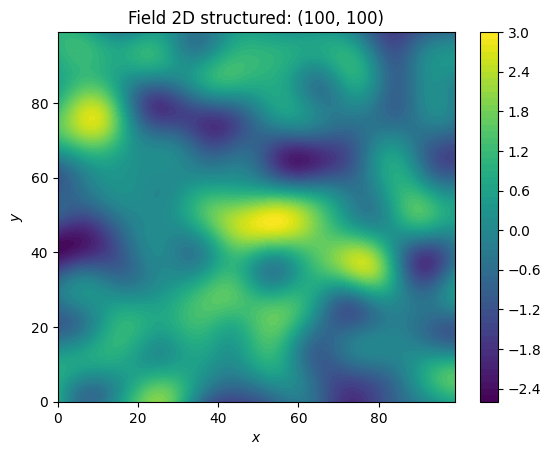

In [1]:
import gstools as gs
# structured field with a size 100x100 and a grid-size of 1x1
x = y = range(100)
model = gs.Gaussian(dim=2, var=1, len_scale=10)
srf = gs.SRF(model)
srf((x, y), mesh_type='structured')
srf.plot()

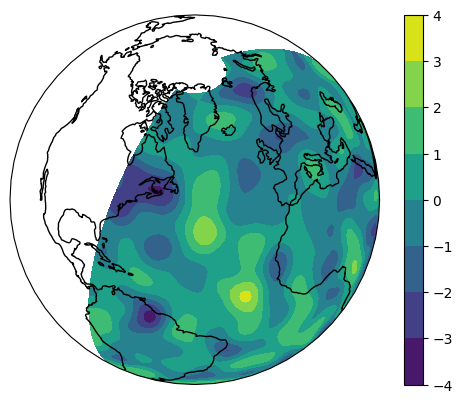

In [2]:
# pip install cartopy

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import gstools as gs
# define a structured field by latitude and longitude
lat = lon = range(-80, 81)
model = gs.Gaussian(latlon=True, len_scale=777, geo_scale=gs.KM_SCALE)
srf = gs.SRF(model, seed=12345)
field = srf.structured((lat, lon))
# Orthographic plotting with cartopy
ax = plt.subplot(projection=ccrs.Orthographic(-45, 45))
cont = ax.contourf(lon, lat, field, transform=ccrs.PlateCarree())
ax.coastlines()
ax.set_global()
plt.colorbar(cont)

In [ ]:
%pip install pyvista

C:\Users\barbe\AppData\Local\Temp\ipykernel_6844\1225815003.py:10: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.contour(isosurfaces=8).plot()


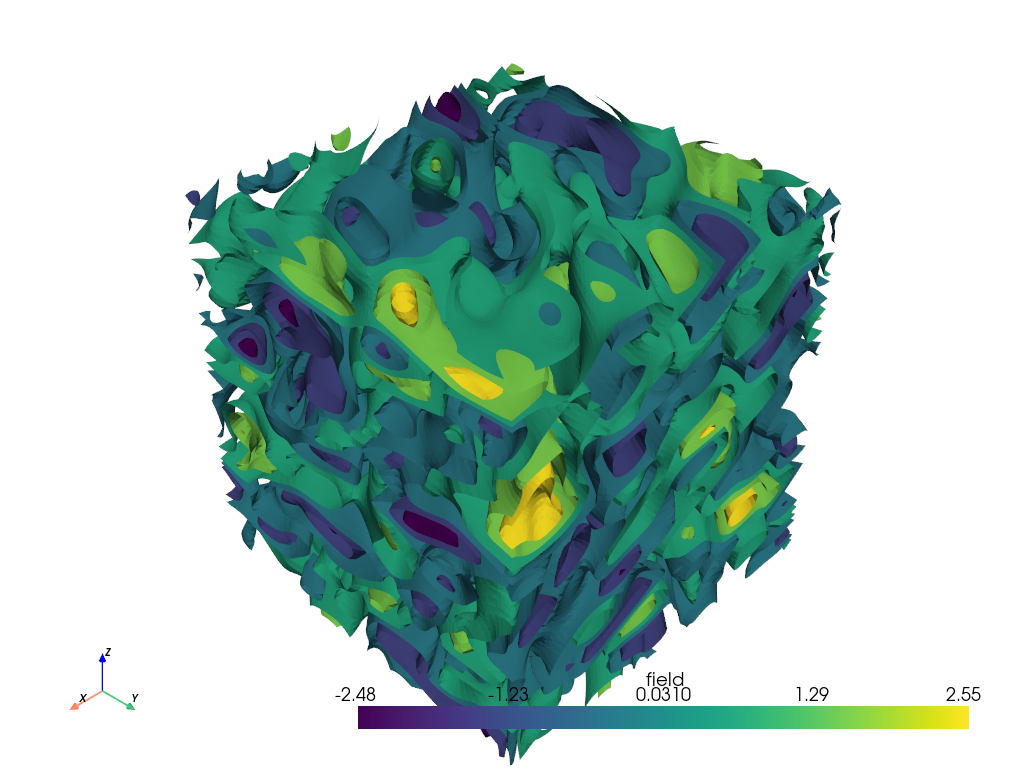

In [3]:

import gstools as gs
# structured field with a size 100x100x100 and a grid-size of 1x1x1
x = y = z = range(100)
model = gs.Gaussian(dim=3, len_scale=[16, 8, 4], angles=(0.8, 0.4, 0.2))
srf = gs.SRF(model)
srf((x, y, z), mesh_type='structured')
srf.vtk_export('3d_field') # Save to a VTK file for ParaView

mesh = srf.to_pyvista() # Create a PyVista mesh for plotting in Python
mesh.contour(isosurfaces=8).plot()

## Estimating and fitting variograms

The spatial structure of a field can be analyzed with the variogram, which contains the same information as the covariance function.

All covariance models can be used to fit given variogram data by a simple interface.

Examples

This is an example of how to estimate the variogram of a 2 dimensional unstructured field and estimate the parameters of the covariance model again.

Stable(dim=2, var=1.85, len_scale=7.42, alpha=1.09)


C:\Users\barbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\gstools\covmodel\plot.py:134: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


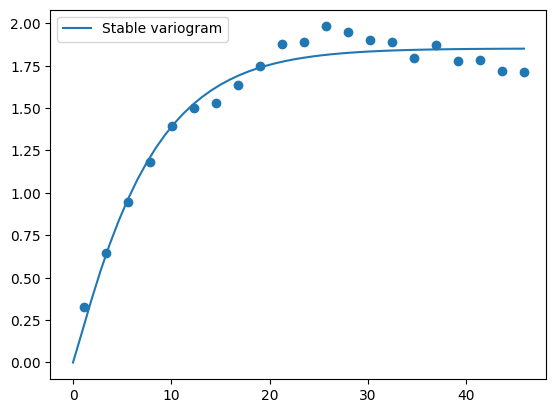

In [4]:
import numpy as np
import gstools as gs
# generate a synthetic field with an exponential model
x = np.random.RandomState(19970221).rand(1000) * 100.
y = np.random.RandomState(20011012).rand(1000) * 100.
model = gs.Exponential(dim=2, var=2, len_scale=8)
srf = gs.SRF(model, mean=0, seed=19970221)
field = srf((x, y))
# estimate the variogram of the field
bin_center, gamma = gs.vario_estimate((x, y), field)
# fit the variogram with a stable model. (no nugget fitted)
fit_model = gs.Stable(dim=2)
fit_model.fit_variogram(bin_center, gamma, nugget=False)
# output
ax = fit_model.plot(x_max=max(bin_center))
ax.scatter(bin_center, gamma)
print(fit_model)

## Kriging and Conditioned Random Fields

An important part of geostatistics is Kriging and conditioning spatial random fields to measurements. With conditioned random fields, an ensemble of field realizations with their variability depending on the proximity of the measurements can be generated.

 Example

For better visualization, we will condition a 1d field to a few “measurements”, generate 100 realizations and plot them:

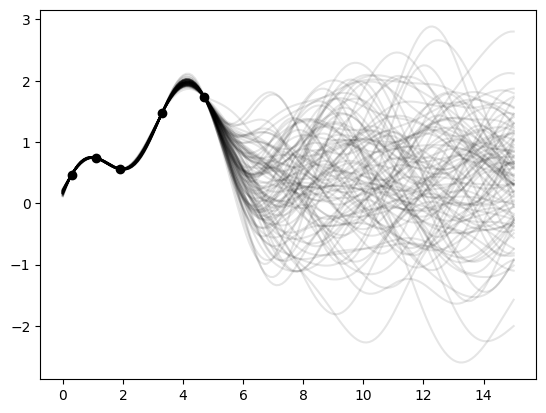

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import gstools as gs

# conditions
cond_pos = [0.3, 1.9, 1.1, 3.3, 4.7]
cond_val = [0.47, 0.56, 0.74, 1.47, 1.74]

# conditioned spatial random field class
model = gs.Gaussian(dim=1, var=0.5, len_scale=2)
krige = gs.krige.Ordinary(model, cond_pos, cond_val)
cond_srf = gs.CondSRF(krige)
# same output positions for all ensemble members
grid_pos = np.linspace(0.0, 15.0, 151)
cond_srf.set_pos(grid_pos)

# seeded ensemble generation
seed = gs.random.MasterRNG(20170519)
for i in range(100):
    field = cond_srf(seed=seed(), store=f"field_{i}")
    plt.plot(grid_pos, field, color="k", alpha=0.1)
plt.scatter(cond_pos, cond_val, color="k")
plt.show()

# User defined covariance models
One of the core-features of GSTools is the powerful CovModel class, which allows to easy define covariance models by the user.

Example
Here we re-implement the Gaussian covariance model by defining just the correlation function, which takes a non-dimensional distance h = r/l

In [7]:
import numpy as np
import gstools as gs
# use CovModel as the base-class
class Gau(gs.CovModel):
    def cor(self, h):
        return np.exp(-h**2)

# Incompressible Vector Field Generation
Using the original Kraichnan method, incompressible random spatial vector fields can be generated.

Example

C:\Users\barbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\gstools\field\plot.py:351: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Axes: title={'center': 'Field 2D structured: (2, 100, 100)'}, xlabel='X', ylabel='Y'>

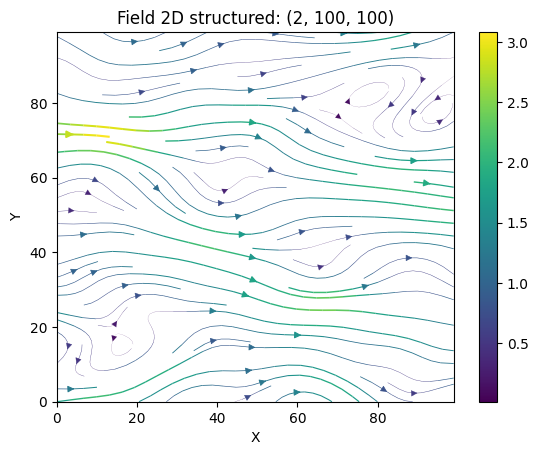

In [8]:
import numpy as np
import gstools as gs
x = np.arange(100)
y = np.arange(100)
model = gs.Gaussian(dim=2, var=1, len_scale=10)
srf = gs.SRF(model, generator='VectorField', seed=19841203)
srf((x, y), mesh_type='structured')
srf.plot()

# Plurigaussian Field Simulation (PGS)
With PGS, more complex categorical (or discrete) fields can be created.

Example

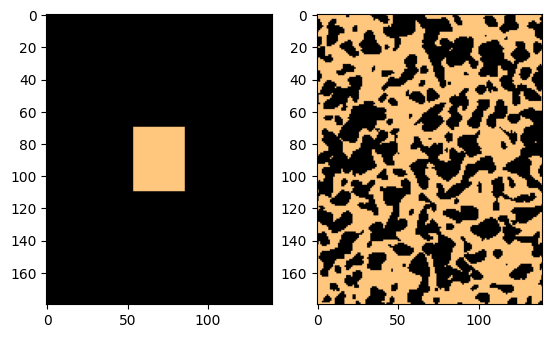

In [9]:
import gstools as gs
import numpy as np
import matplotlib.pyplot as plt

N = [180, 140]

x, y = range(N[0]), range(N[1])

# we need 2 SRFs
model = gs.Gaussian(dim=2, var=1, len_scale=5)
srf = gs.SRF(model)
field1 = srf.structured([x, y], seed=20170519)
field2 = srf.structured([x, y], seed=19970221)

# with `lithotypes`, we prescribe the categorical data and its relations
# here, we use 2 categories separated by a rectangle.
rect = [40, 32]
lithotypes = np.zeros(N)
lithotypes[
    N[0] // 2 - rect[0] // 2 : N[0] // 2 + rect[0] // 2,
    N[1] // 2 - rect[1] // 2 : N[1] // 2 + rect[1] // 2,
] = 1

pgs = gs.PGS(2, [field1, field2])
P = pgs(lithotypes)

fig, axs = plt.subplots(1, 2)
axs[0].imshow(lithotypes, cmap="copper")
axs[1].imshow(P, cmap="copper")
plt.show()

# VTK/PyVista Export
After you have created a field, you may want to save it to file, so we provide a handy VTK export routine using the vtk_export() or you could create a VTK/PyVista dataset for use in Python with to to_pyvista() method:

C:\Users\barbe\AppData\Local\Temp\ipykernel_6844\1307298836.py:8: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.plot()


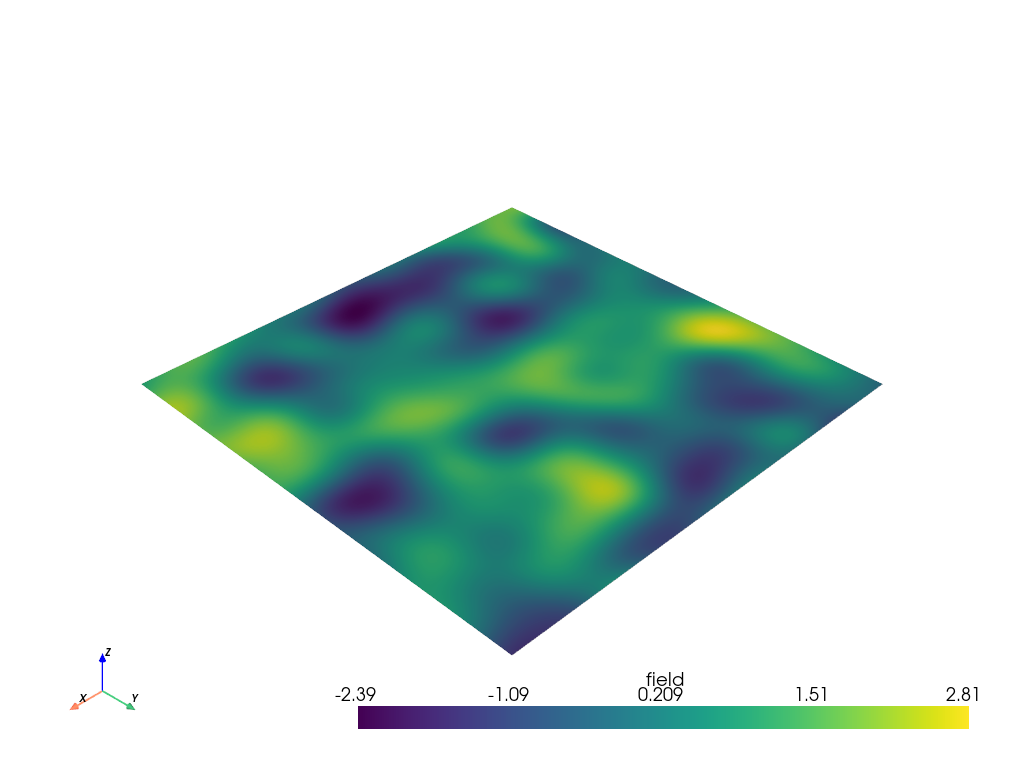

In [10]:

import gstools as gs
x = y = range(100)
model = gs.Gaussian(dim=2, var=1, len_scale=10)
srf = gs.SRF(model)
srf((x, y), mesh_type='structured')
srf.vtk_export("field") # Saves to a VTK file
mesh = srf.to_pyvista() # Create a VTK/PyVista dataset in memory
mesh.plot()